In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="deep")

PROJECT_ROOT = Path(r"C:\Users\Hrugved\OneDrive\Desktop\bluestock")
PROCESSED_DIR = Path(r"C:\Users\Hrugved\OneDrive\Desktop\bluestock\data\processed")

NAV_PATH = PROCESSED_DIR / "nav_history_clean.csv"
BENCHMARK_PATH = PROCESSED_DIR / "benchmark_indices_clean.csv"
FUND_MASTER_PATH = PROCESSED_DIR / "fund_master_clean.csv"
SCHEME_PERFORMANCE_PATH = PROCESSED_DIR / "scheme_performance_clean.csv"

ALPHA_BETA_OUTPUT = PROJECT_ROOT / "alpha_beta.csv"
SCORECARD_OUTPUT = PROJECT_ROOT / "fund_scorecard.csv"
BENCHMARK_CHART_OUTPUT = PROJECT_ROOT / "benchmark_comparison.png"

TRADING_DAYS = 252
RISK_FREE_RATE = 0.065

In [2]:
nav_df = pd.read_csv(NAV_PATH)
benchmark_df = pd.read_csv(BENCHMARK_PATH)
fund_master_df = pd.read_csv(FUND_MASTER_PATH)
scheme_performance_df = pd.read_csv(SCHEME_PERFORMANCE_PATH)

dataframes = {
    "nav_df": nav_df,
    "benchmark_df": benchmark_df,
    "fund_master_df": fund_master_df,
    "scheme_performance_df": scheme_performance_df,
}

for name, frame in dataframes.items():
    date_columns = [column for column in frame.columns if "date" in column.lower()]
    for column in date_columns:
        frame[column] = pd.to_datetime(frame[column], errors="coerce")
    print(f"{name}: {frame.shape[0]:,} rows x {frame.shape[1]:,} columns")

nav_df["amfi_code"] = nav_df["amfi_code"].astype(str)
fund_master_df["amfi_code"] = fund_master_df["amfi_code"].astype(str)
scheme_performance_df["amfi_code"] = scheme_performance_df["amfi_code"].astype(str)

display(nav_df.head())
display(benchmark_df.head())
display(fund_master_df.head())

nav_df: 46,000 rows x 3 columns
benchmark_df: 8,050 rows x 3 columns
fund_master_df: 40 rows x 15 columns
scheme_performance_df: 40 rows x 19 columns


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.7900
1,2022-01-04,NIFTY50,17689.6400
2,2022-01-05,NIFTY50,17835.0500
3,2022-01-06,NIFTY50,17878.5100
4,2022-01-07,NIFTY50,17759.1500


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.5400,1.0000,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.6600,1.0000,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.4300,1.0000,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.7200,1.0000,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.7700,0.0000,500,1000,Dinesh Ahuja,Low,DC02


,daily_return
count,45960.0000
mean,0.0006
std,0.0103
min,-0.0581
1%,-0.0260
5%,-0.0163
25%,-0.0050
50%,0.0003
75%,0.0063
95%,0.0178


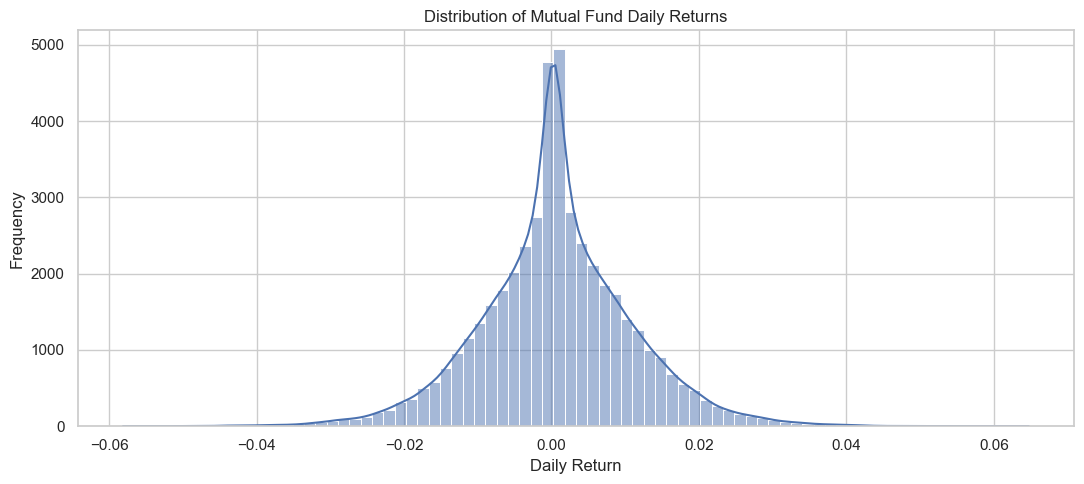

In [3]:
nav_df = nav_df.sort_values(["amfi_code", "date"]).reset_index(drop=True)
nav_df["daily_return"] = nav_df.groupby("amfi_code")["nav"].pct_change()

daily_return_summary = nav_df["daily_return"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
display(daily_return_summary.to_frame("daily_return"))

plt.figure(figsize=(11, 5))
sns.histplot(nav_df["daily_return"].dropna(), bins=80, kde=True)
plt.title("Distribution of Mutual Fund Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [4]:
def calculate_cagr_for_period(group: pd.DataFrame, years: int) -> float:
    group = group.dropna(subset=["date", "nav"]).sort_values("date")
    if group.empty:
        return np.nan

    end_date = group["date"].max()
    start_cutoff = end_date - pd.DateOffset(years=years)
    period = group[group["date"] >= start_cutoff]

    if period.empty:
        return np.nan

    start_row = period.iloc[0]
    end_row = period.iloc[-1]
    elapsed_years = (end_row["date"] - start_row["date"]).days / 365.25

    if elapsed_years < years * 0.80 or start_row["nav"] <= 0:
        return np.nan

    return (end_row["nav"] / start_row["nav"]) ** (1 / elapsed_years) - 1


cagr_records = []
for amfi_code, group in nav_df.groupby("amfi_code"):
    cagr_records.append(
        {
            "amfi_code": amfi_code,
            "cagr_1yr": calculate_cagr_for_period(group, 1),
            "cagr_3yr": calculate_cagr_for_period(group, 3),
            "cagr_5yr": calculate_cagr_for_period(group, 5),
        }
    )

cagr_df = pd.DataFrame(cagr_records)
cagr_comparison = cagr_df.merge(
    fund_master_df[["amfi_code", "scheme_name", "category", "plan"]],
    on="amfi_code",
    how="left",
)

display(cagr_comparison.sort_values("cagr_3yr", ascending=False).head(15))

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,scheme_name,category,plan
16,119094,0.2228,0.3510,0.2821,Axis Midcap Fund - Regular - Growth,Equity,Regular
34,148567,0.2038,0.3399,0.3097,Mirae Asset Large Cap Fund - Regular - Growth,Equity,Regular
24,120504,0.1307,0.3248,0.2330,ICICI Pru Bluechip Fund - Direct - Growth,Equity,Direct
2,100033,0.5328,0.3243,0.3012,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,Regular
25,120505,0.2963,0.3177,0.3283,ICICI Pru Midcap Fund - Regular - Growth,Equity,Regular
19,119551,0.6049,0.3045,0.2580,SBI Bluechip Fund - Regular Plan - Growth,Equity,Regular
30,120843,0.2668,0.2958,0.3091,Kotak Flexicap Fund - Regular - Growth,Equity,Regular
36,148569,0.3978,0.2917,0.3195,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,Regular
3,101206,0.4796,0.2896,0.2354,ABSL Frontline Equity Fund - Regular - Growth,Equity,Regular
39,149324,0.6520,0.2699,0.3229,DSP Small Cap Fund - Regular - Growth,Equity,Regular


In [5]:
def calculate_sharpe(group: pd.DataFrame) -> pd.Series:
    returns = group["daily_return"].dropna()
    if returns.empty or returns.std(ddof=1) == 0:
        return pd.Series({"annual_return": np.nan, "annual_volatility": np.nan, "sharpe_ratio": np.nan})

    annual_return = returns.mean() * TRADING_DAYS
    annual_volatility = returns.std(ddof=1) * np.sqrt(TRADING_DAYS)
    sharpe_ratio = (annual_return - RISK_FREE_RATE) / annual_volatility
    return pd.Series(
        {
            "annual_return": annual_return,
            "annual_volatility": annual_volatility,
            "sharpe_ratio": sharpe_ratio,
        }
    )


sharpe_df = nav_df.groupby("amfi_code").apply(calculate_sharpe).reset_index()
sharpe_ranking = sharpe_df.merge(
    fund_master_df[["amfi_code", "scheme_name", "category", "plan"]],
    on="amfi_code",
    how="left",
).sort_values("sharpe_ratio", ascending=False)

display(sharpe_ranking.head(20))

,amfi_code,annual_return,annual_volatility,sharpe_ratio,scheme_name,category,plan
34,148567,0.2706,0.1419,1.4483,Mirae Asset Large Cap Fund - Regular - Growth,Equity,Regular
30,120843,0.2726,0.1589,1.3067,Kotak Flexicap Fund - Regular - Growth,Equity,Regular
36,148569,0.2833,0.1767,1.2349,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,Regular
19,119551,0.2310,0.1374,1.2083,SBI Bluechip Fund - Regular Plan - Growth,Equity,Regular
25,120505,0.2927,0.1929,1.1801,ICICI Pru Midcap Fund - Regular - Growth,Equity,Regular
38,149323,0.2659,0.1775,1.1321,DSP Midcap Fund - Regular - Growth,Equity,Regular
2,100033,0.2721,0.1894,1.0937,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,Regular
9,118632,0.2180,0.1415,1.0817,Nippon India Large Cap Fund - Regular - Growth,Equity,Regular
3,101206,0.2146,0.1457,1.0272,ABSL Frontline Equity Fund - Regular - Growth,Equity,Regular
24,120504,0.2124,0.1436,1.0265,ICICI Pru Bluechip Fund - Direct - Growth,Equity,Direct


In [6]:
def calculate_sortino(group: pd.DataFrame) -> pd.Series:
    returns = group["daily_return"].dropna()
    downside_returns = returns[returns < 0]

    if returns.empty or downside_returns.empty or downside_returns.std(ddof=1) == 0:
        return pd.Series({"downside_deviation": np.nan, "sortino_ratio": np.nan})

    annual_return = returns.mean() * TRADING_DAYS
    downside_deviation = downside_returns.std(ddof=1) * np.sqrt(TRADING_DAYS)
    sortino_ratio = (annual_return - RISK_FREE_RATE) / downside_deviation
    return pd.Series({"downside_deviation": downside_deviation, "sortino_ratio": sortino_ratio})


sortino_df = nav_df.groupby("amfi_code").apply(calculate_sortino).reset_index()
sortino_ranking = sortino_df.merge(
    fund_master_df[["amfi_code", "scheme_name", "category", "plan"]],
    on="amfi_code",
    how="left",
).sort_values("sortino_ratio", ascending=False)

display(sortino_ranking.head(20))

,amfi_code,downside_deviation,sortino_ratio,scheme_name,category,plan
34,148567,0.0862,2.3856,Mirae Asset Large Cap Fund - Regular - Growth,Equity,Regular
30,120843,0.0878,2.3643,Kotak Flexicap Fund - Regular - Growth,Equity,Regular
36,148569,0.1017,2.1469,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,Regular
19,119551,0.0776,2.1403,SBI Bluechip Fund - Regular Plan - Growth,Equity,Regular
25,120505,0.1122,2.0294,ICICI Pru Midcap Fund - Regular - Growth,Equity,Regular
38,149323,0.1071,1.8751,DSP Midcap Fund - Regular - Growth,Equity,Regular
9,118632,0.0827,1.8501,Nippon India Large Cap Fund - Regular - Growth,Equity,Regular
2,100033,0.1132,1.8291,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,Regular
24,120504,0.0817,1.8053,ICICI Pru Bluechip Fund - Direct - Growth,Equity,Direct
3,101206,0.0832,1.7996,ABSL Frontline Equity Fund - Regular - Growth,Equity,Regular


In [7]:
def benchmark_series(index_name: str) -> pd.DataFrame:
    normalized_name = index_name.upper().replace(" ", "")
    frame = benchmark_df[
        benchmark_df["index_name"].astype(str).str.upper().str.replace(" ", "", regex=False) == normalized_name
    ].copy()
    if frame.empty:
        available = sorted(benchmark_df["index_name"].dropna().unique())
        raise ValueError(f"Benchmark {index_name!r} not found. Available benchmarks: {available}")
    frame = frame.sort_values("date")
    frame["benchmark_return"] = frame["close_value"].pct_change()
    return frame[["date", "close_value", "benchmark_return"]]


nifty100_returns = benchmark_series("NIFTY100").dropna(subset=["benchmark_return"])

alpha_beta_records = []
for amfi_code, group in nav_df.groupby("amfi_code"):
    merged_returns = group[["date", "daily_return"]].merge(nifty100_returns[["date", "benchmark_return"]], on="date", how="inner")
    merged_returns = merged_returns.dropna(subset=["daily_return", "benchmark_return"])

    if len(merged_returns) < 30 or merged_returns["benchmark_return"].std(ddof=1) == 0:
        alpha = np.nan
        beta = np.nan
    else:
        regression = linregress(merged_returns["benchmark_return"], merged_returns["daily_return"])
        beta = regression.slope
        alpha = regression.intercept * TRADING_DAYS

    alpha_beta_records.append({"amfi_code": amfi_code, "alpha": alpha, "beta": beta})

alpha_beta_df = pd.DataFrame(alpha_beta_records)
alpha_beta_df.to_csv(ALPHA_BETA_OUTPUT, index=False)

alpha_beta_ranking = alpha_beta_df.merge(
    fund_master_df[["amfi_code", "scheme_name", "category", "plan"]],
    on="amfi_code",
    how="left",
).sort_values("alpha", ascending=False)

display(alpha_beta_ranking.head(20))
print(f"Exported alpha and beta data to: {ALPHA_BETA_OUTPUT}")

,amfi_code,alpha,beta,scheme_name,category,plan
21,119598,0.3034,-0.0232,SBI Small Cap Fund - Regular Plan - Growth,Equity,Regular
39,149324,0.3006,0.0115,DSP Small Cap Fund - Regular - Growth,Equity,Regular
25,120505,0.2926,0.0005,ICICI Pru Midcap Fund - Regular - Growth,Equity,Regular
36,148569,0.2827,0.0181,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,Regular
30,120843,0.2733,-0.0228,Kotak Flexicap Fund - Regular - Growth,Equity,Regular
2,100033,0.2720,0.0051,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,Regular
34,148567,0.2698,0.0237,Mirae Asset Large Cap Fund - Regular - Growth,Equity,Regular
38,149323,0.2660,-0.0025,DSP Midcap Fund - Regular - Growth,Equity,Regular
16,119094,0.2608,-0.0663,Axis Midcap Fund - Regular - Growth,Equity,Regular
19,119551,0.2320,-0.0318,SBI Bluechip Fund - Regular Plan - Growth,Equity,Regular


Exported alpha and beta data to: C:\Users\Hrugved\OneDrive\Desktop\bluestock\alpha_beta.csv


In [8]:
def calculate_max_drawdown(group: pd.DataFrame) -> pd.Series:
    group = group.dropna(subset=["date", "nav"]).sort_values("date").copy()
    if group.empty:
        return pd.Series({"maximum_drawdown": np.nan, "drawdown_start_date": pd.NaT, "drawdown_end_date": pd.NaT})

    group["running_max"] = group["nav"].cummax()
    group["drawdown"] = group["nav"] / group["running_max"] - 1
    trough_idx = group["drawdown"].idxmin()
    trough_date = group.loc[trough_idx, "date"]
    trough_drawdown = group.loc[trough_idx, "drawdown"]

    peak_window = group.loc[:trough_idx]
    peak_idx = peak_window["nav"].idxmax()
    peak_date = group.loc[peak_idx, "date"]

    return pd.Series(
        {
            "maximum_drawdown": trough_drawdown,
            "drawdown_start_date": peak_date,
            "drawdown_end_date": trough_date,
        }
    )


drawdown_df = nav_df.groupby("amfi_code").apply(calculate_max_drawdown).reset_index()
drawdown_summary = drawdown_df.merge(
    fund_master_df[["amfi_code", "scheme_name", "category", "plan"]],
    on="amfi_code",
    how="left",
).sort_values("maximum_drawdown", ascending=False)

display(drawdown_summary.head(20))

,amfi_code,maximum_drawdown,drawdown_start_date,drawdown_end_date,scheme_name,category,plan
27,120507,-0.0010,2025-10-16,2025-10-20,ICICI Pru Liquid Fund - Regular - Growth,Debt,Regular
31,120844,-0.0012,2024-04-12,2024-04-30,Kotak Liquid Fund - Regular - Growth,Debt,Regular
5,101208,-0.0016,2023-09-05,2023-09-12,ABSL Liquid Fund - Regular - Growth,Debt,Regular
1,100025,-0.0431,2023-05-23,2023-07-28,HDFC Short Term Debt Fund - Regular - Growth,Debt,Regular
18,119120,-0.0433,2024-09-16,2025-04-01,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Regular
13,118636,-0.0832,2023-02-09,2024-02-09,Nippon India Gilt Securities Fund - Regular - ...,Debt,Regular
6,102885,-0.1086,2022-02-03,2022-03-29,UTI Nifty 50 Index Fund - Regular - Growth,Equity,Regular
34,148567,-0.1127,2023-07-11,2023-10-20,Mirae Asset Large Cap Fund - Regular - Growth,Equity,Regular
3,101206,-0.1129,2023-04-24,2023-07-05,ABSL Frontline Equity Fund - Regular - Growth,Equity,Regular
12,118635,-0.1165,2022-01-03,2022-06-09,Nippon India ETF Nifty 50 BeES,Equity,Direct


In [9]:
scorecard = (
    fund_master_df[["amfi_code", "scheme_name", "fund_house", "category", "plan", "expense_ratio_pct"]]
    .merge(cagr_df, on="amfi_code", how="left")
    .merge(sharpe_df[["amfi_code", "sharpe_ratio"]], on="amfi_code", how="left")
    .merge(alpha_beta_df, on="amfi_code", how="left")
    .merge(drawdown_df[["amfi_code", "maximum_drawdown", "drawdown_start_date", "drawdown_end_date"]], on="amfi_code", how="left")
)

scorecard["return_3yr_score"] = scorecard["cagr_3yr"].rank(pct=True, ascending=True) * 100
scorecard["sharpe_score"] = scorecard["sharpe_ratio"].rank(pct=True, ascending=True) * 100
scorecard["alpha_score"] = scorecard["alpha"].rank(pct=True, ascending=True) * 100
scorecard["expense_score"] = scorecard["expense_ratio_pct"].rank(pct=True, ascending=False) * 100
scorecard["drawdown_score"] = scorecard["maximum_drawdown"].rank(pct=True, ascending=True) * 100

score_components = ["return_3yr_score", "sharpe_score", "alpha_score", "expense_score", "drawdown_score"]
scorecard[score_components] = scorecard[score_components].fillna(scorecard[score_components].median())

scorecard["weighted_score"] = (
    scorecard["return_3yr_score"] * 0.30
    + scorecard["sharpe_score"] * 0.25
    + scorecard["alpha_score"] * 0.20
    + scorecard["expense_score"] * 0.15
    + scorecard["drawdown_score"] * 0.10
)

score_min = scorecard["weighted_score"].min()
score_max = scorecard["weighted_score"].max()
if pd.notna(score_min) and pd.notna(score_max) and score_max > score_min:
    scorecard["fund_score"] = (scorecard["weighted_score"] - score_min) / (score_max - score_min) * 100
else:
    scorecard["fund_score"] = 100.0

fund_scorecard = scorecard.sort_values("fund_score", ascending=False).reset_index(drop=True)
fund_scorecard.to_csv(SCORECARD_OUTPUT, index=False)

display(fund_scorecard.head(20))
print(f"Exported fund scorecard to: {SCORECARD_OUTPUT}")

,amfi_code,scheme_name,fund_house,category,plan,expense_ratio_pct,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,alpha,beta,maximum_drawdown,drawdown_start_date,drawdown_end_date,return_3yr_score,sharpe_score,alpha_score,expense_score,drawdown_score,weighted_score,fund_score
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,Regular,1.4600,0.2038,0.3399,0.3097,1.4483,0.2698,0.0237,-0.1127,2023-07-11,2023-10-20,97.5000,100.0000,85.0000,45.0000,82.5000,86.2500,100.0000
1,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,Regular,1.3600,0.2963,0.3177,0.3283,1.1801,0.2926,0.0005,-0.1819,2024-10-24,2025-01-23,90.0000,90.0000,95.0000,65.0000,40.0000,82.2500,94.4396
2,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,Regular,1.4500,0.2668,0.2958,0.3091,1.3067,0.2733,-0.0228,-0.1297,2022-03-07,2022-04-13,85.0000,97.5000,90.0000,47.5000,70.0000,82.0000,94.0921
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,Regular,1.3800,0.5328,0.3243,0.3012,1.0937,0.2720,0.0051,-0.1622,2022-03-11,2022-05-12,92.5000,85.0000,87.5000,60.0000,52.5000,80.7500,92.3545
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Equity,Direct,0.8000,0.1307,0.3248,0.2330,1.0265,0.2119,0.0162,-0.1259,2022-10-04,2023-05-30,95.0000,77.5000,70.0000,72.5000,72.5000,80.0000,91.3119
5,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,Regular,1.3800,0.2228,0.3510,0.2821,0.9982,0.2608,-0.0663,-0.2096,2022-04-14,2022-08-11,100.0000,75.0000,80.0000,60.0000,32.5000,77.0000,87.1416
6,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,Regular,1.5400,0.6049,0.3045,0.2580,1.2083,0.2320,-0.0318,-0.1501,2023-08-24,2024-02-05,87.5000,92.5000,77.5000,26.2500,60.0000,74.8125,84.1008
7,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,Regular,1.6000,0.3978,0.2917,0.3195,1.2349,0.2827,0.0181,-0.1640,2023-08-10,2023-10-20,82.5000,95.0000,92.5000,11.2500,50.0000,73.6875,82.5369
8,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Regular,1.6000,0.4796,0.2896,0.2354,1.0272,0.2140,0.0211,-0.1129,2023-04-24,2023-07-05,80.0000,80.0000,72.5000,11.2500,80.0000,68.1875,74.8914
9,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,Regular,1.4300,0.8285,0.2666,0.3242,0.9453,0.3034,-0.0232,-0.2871,2024-08-28,2025-05-14,72.5000,67.5000,100.0000,50.0000,12.5000,67.3750,73.7619


Exported fund scorecard to: C:\Users\Hrugved\OneDrive\Desktop\bluestock\fund_scorecard.csv


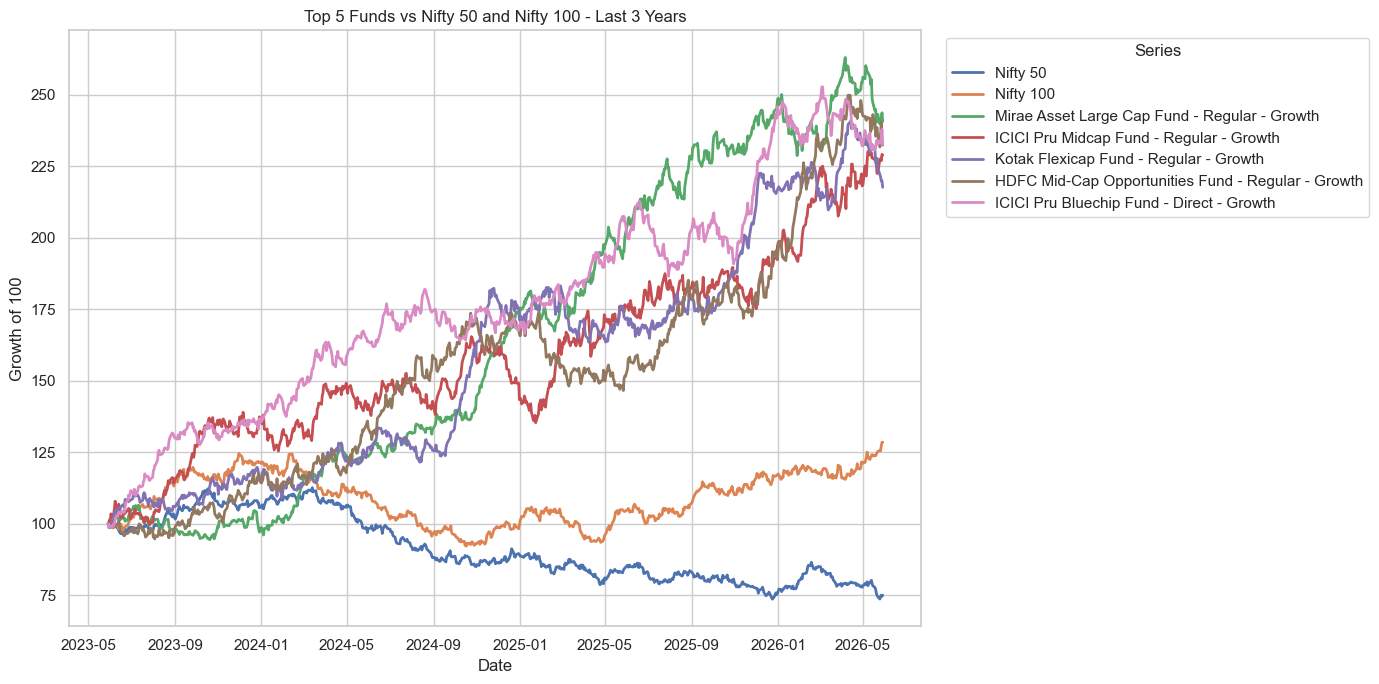

,amfi_code,scheme_name,fund_score,tracking_error_vs_nifty100
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,91.3119,0.1873
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,100.0000,0.1879
2,120843,Kotak Flexicap Fund - Regular - Growth,94.0921,0.2064
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,92.3545,0.2248
1,120505,ICICI Pru Midcap Fund - Regular - Growth,94.4396,0.2325


Exported benchmark comparison chart to: C:\Users\Hrugved\OneDrive\Desktop\bluestock\benchmark_comparison.png


In [10]:
top_5_funds = fund_scorecard.head(5)[["amfi_code", "scheme_name", "fund_score"]].copy()
nifty50 = benchmark_series("NIFTY50")
nifty100 = benchmark_series("NIFTY100")

comparison_end_date = min(nav_df["date"].max(), nifty50["date"].max(), nifty100["date"].max())
comparison_start_date = comparison_end_date - pd.DateOffset(years=3)

def normalized_series(frame: pd.DataFrame, value_column: str, label: str) -> pd.DataFrame:
    subset = frame.loc[
        (frame["date"] >= comparison_start_date) & (frame["date"] <= comparison_end_date),
        ["date", value_column],
    ].dropna().sort_values("date")
    if subset.empty:
        return pd.DataFrame(columns=["date", "label", "normalized_value"])
    subset["normalized_value"] = subset[value_column] / subset[value_column].iloc[0] * 100
    subset["label"] = label
    return subset[["date", "label", "normalized_value"]]


comparison_frames = [
    normalized_series(nifty50, "close_value", "Nifty 50"),
    normalized_series(nifty100, "close_value", "Nifty 100"),
]

for _, row in top_5_funds.iterrows():
    fund_history = nav_df[nav_df["amfi_code"] == row["amfi_code"]]
    label = row["scheme_name"] if pd.notna(row["scheme_name"]) else row["amfi_code"]
    comparison_frames.append(normalized_series(fund_history, "nav", label))

comparison_plot_df = pd.concat(comparison_frames, ignore_index=True)

plt.figure(figsize=(14, 7))
sns.lineplot(data=comparison_plot_df, x="date", y="normalized_value", hue="label", linewidth=2)
plt.title("Top 5 Funds vs Nifty 50 and Nifty 100 - Last 3 Years")
plt.xlabel("Date")
plt.ylabel("Growth of 100")
plt.legend(title="Series", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(BENCHMARK_CHART_OUTPUT, dpi=300, bbox_inches="tight")
plt.show()

tracking_error_records = []
benchmark_tracking_returns = nifty100[["date", "benchmark_return"]].rename(columns={"benchmark_return": "nifty100_return"})

for _, row in top_5_funds.iterrows():
    fund_returns = nav_df.loc[
        (nav_df["amfi_code"] == row["amfi_code"])
        & (nav_df["date"] >= comparison_start_date)
        & (nav_df["date"] <= comparison_end_date),
        ["date", "daily_return"],
    ]
    tracking_data = fund_returns.merge(benchmark_tracking_returns, on="date", how="inner").dropna()

    if tracking_data.empty:
        tracking_error = np.nan
    else:
        tracking_error = (tracking_data["daily_return"] - tracking_data["nifty100_return"]).std(ddof=1) * np.sqrt(TRADING_DAYS)

    tracking_error_records.append(
        {
            "amfi_code": row["amfi_code"],
            "scheme_name": row["scheme_name"],
            "fund_score": row["fund_score"],
            "tracking_error_vs_nifty100": tracking_error,
        }
    )

tracking_error_df = pd.DataFrame(tracking_error_records).sort_values("tracking_error_vs_nifty100")
display(tracking_error_df)
print(f"Exported benchmark comparison chart to: {BENCHMARK_CHART_OUTPUT}")